<a href="https://colab.research.google.com/github/fidanismayilzada23/Nova_finance_analiysis/blob/main/nova_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
from datetime import datetime, timedelta
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#IMPORT DATA

In [ ]:
df= pd.read_csv('/content/Finance_Ecommerce_Dirty_Dataset_csv.csv')

In [ ]:
data=df.copy()

#EDA


In [ ]:
pd.set_option('display.max_columns',None)
df.head()

,TransactionID,Date,AccountID,AccountName,TransactionType,Amount,Currency,ExchangeRate,Balance,Merchant,MerchantPhone,MerchantEmail,Category,Subcategory,Country,City,PostalCode,CardNumber,Email,Phone,IsFraud,Notes,CustomerSince
0,TX103251,4/3/2025,AC3973,Arjun Sharma,Debit,47.36,USD,80.6864,-1714968.59,ShopEasy,NaN,shopeasy@biz.com,Education,Books,UK,Pune,153621.0,XXXX-XXXX-XXXX-4249,arjun.sharma@hotmail.com,-4.469492e+09,No,repeat purchase,16/09/2018
1,TX101874,10/8/2024,AC8970,Dev Kumar,Debit,159.55,inr,1.0000,-1162428.75,AutoZone,1.856170e+09,autozone@biz.com,Entertainment,Concert,Australia,Delhi,380312.0,XXXX-XXXX-5979,dev.kumar@yahoo.com,5.882006e+09,No,cashback credited,11/7/2022
2,TX103746,9/14/2024,AC3777,Amit Gupta,Debit,2.43,GBP,102.0148,-2085783.34,BigBasket,3.232507e+08,bigbasket@biz.com,Groceries,Specialty,USA,Gurugram,NaN,XXXX-XXXX-2243,amit.gupta@example.com,8.832898e+08,No,cashback credited,Aug-21
3,TX105269,12/21/2024,AC9635,Ritu Roy,Refund,78.96,AED,18.1216,-2727243.49,ShopEasy,NaN,shopeasy@biz.com,Dining,Restaurant,Australia,Mumbai,793747.0,XXXX-XXXX-9279,ritu.roy@hotmail.com,6.845400e+09,No,suspected fraud,2024
4,TX100463,4/14/2024,AC1329,Raj Bose,Refund,42.81,USD,78.4379,-259175.06,LocalMart,6.762861e+08,NaN,Dining,FastFood,USA,Mumbai,755067.0,NaN,raj.bose@hotmail.com,1.228611e+09,No,cashback credited,3/2/2023


In [ ]:
df.tail()

,TransactionID,Date,AccountID,AccountName,TransactionType,Amount,Currency,ExchangeRate,Balance,Merchant,MerchantPhone,MerchantEmail,Category,Subcategory,Country,City,PostalCode,CardNumber,Email,Phone,IsFraud,Notes,CustomerSince
6055,TX105699,10/16/2023,AC5214,Vikram Iyer,Credit,69.09,USD,76.4757,"?-2,901,016.18",AutoZone,9.858342e+09,autozone@biz.com,Travel,Hotel,UAE,Pune,856227.0,XXXX-XXXX-6489,vikram.iyer@yahoo.com,4.081945e+09,No,chargeback requested,2021
6056,TX102550,7/25/2025,AC8982,Anita Reddy,debit,4.94,USD,79.1632,-1557558.39,ShopEasy,3.522591e+09,shopeasy@biz.com,Entertainment,Concert,Australia,Bengaluru,235120.0,XXXX-XXXX-5540,anita.reddy@gmail.com,2.586561e+09,No,monthly subscription,5/27/2023
6057,TX100537,9/24/2023,AC5308,Rohit Kumar,Credit,20.87,AED,19.7547,-276412.59,Amazon,7.629144e+09,amazon@biz.com,Health,Pharmacy,UAE,Mumbai,263866.0,XXXX-XXXX-XXXX-6774,rohit.kumar@hotmail.com,NaN,No,NaN,unknown
6058,TX101220,3/25/2024,AC7593,Sana Reddy,Credit,7.96,USD,76.8570,-593859.37,Reliance,2.329283e+09,reliance@biz.com,Clothing,Men,India,Hyderabad,152222.0,XXXX-XXXX-7745,sana.reddy@yahoo.com,6.866496e+09,No,manual adjustment,Aug-19
6059,TX104271,2/3/2025,AC4810,Neha Reddy,Credit,17.66,INR,1.0000,-2254562.37,ElectroWorld,3.642496e+09,NaN,Electronics,Accessory,UK,Chennai,347582.0,XXXX-XXXX-XXXX-9831,neha.reddy@example.com,1.500553e+09,No,monthly subscription,20/06/2020


In [ ]:
df.shape

(6060, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6060 entries, 0 to 6059
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    6057 non-null   object 
 1   Date             6060 non-null   object 
 2   AccountID        6059 non-null   object 
 3   AccountName      6059 non-null   object 
 4   TransactionType  6058 non-null   object 
 5   Amount           6059 non-null   object 
 6   Currency         6055 non-null   object 
 7   ExchangeRate     6058 non-null   float64
 8   Balance          5988 non-null   object 
 9   Merchant         6058 non-null   object 
 10  MerchantPhone    4647 non-null   float64
 11  MerchantEmail    4222 non-null   object 
 12  Category         6058 non-null   object 
 13  Subcategory      6055 non-null   object 
 14  Country          6058 non-null   object 
 15  City             6058 non-null   object 
 16  PostalCode       5742 non-null   float64
 17  CardNumber    

In [ ]:
df.columns

Index(['TransactionID', 'Date', 'AccountID', 'AccountName', 'TransactionType',
       'Amount', 'Currency', 'ExchangeRate', 'Balance', 'Merchant',
       'MerchantPhone', 'MerchantEmail', 'Category', 'Subcategory', 'Country',
       'City', 'PostalCode', 'CardNumber', 'Email', 'Phone', 'IsFraud',
       'Notes', 'CustomerSince'],
      dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=6060, step=1)

In [ ]:
df.describe()

,ExchangeRate,MerchantPhone,PostalCode,Phone
count,6058.000000,4.647000e+03,5742.000000,5.732000e+03
mean,46.319508,3.094016e+09,534220.496517,2.977499e+09
std,40.254595,4.852691e+09,274401.478310,4.946857e+09
min,1.000000,-9.981343e+09,102.000000,-9.985638e+09
25%,1.000000,7.206737e+08,299628.500000,6.050150e+08
50%,72.091800,3.827888e+09,538097.500000,3.779223e+09
75%,80.274425,6.838675e+09,775529.500000,6.829491e+09
max,109.968400,9.999725e+09,999962.000000,9.999725e+09


In [ ]:
df.isnull().sum()

,0
TransactionID,3
Date,0
AccountID,1
AccountName,1
TransactionType,2
Amount,1
Currency,5
ExchangeRate,2
Balance,72
Merchant,2


Datadakı boşlukları silmek

In [ ]:
for col in df.select_dtypes(include="object").columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("\xa0", "", regex=False)  # gizli boşluq
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

In [ ]:
df.head()
df.select_dtypes("object").apply(lambda x: x.unique()[:5])

,0
TransactionID,"[TX103251, TX101874, TX103746, TX105269, TX100..."
Date,"[4/3/2025, 10/8/2024, 9/14/2024, 12/21/2024, 4..."
AccountID,"[AC3973, AC8970, AC3777, AC9635, AC1329]"
AccountName,"[Arjun Sharma, Dev Kumar, Amit Gupta, Ritu Roy..."
TransactionType,"[Debit, Refund, Credit, CREDIT, debit]"
Amount,"[47.36, 159.55, 2.43, 78.96, 42.81]"
Currency,"[USD, inr, GBP, AED, INR]"
Balance,"[-1714968.59, -1162428.75, -2085783.34, -27272..."
Merchant,"[ShopEasy, AutoZone, BigBasket, LocalMart, Ama..."
MerchantEmail,"[shopeasy@biz.com, autozone@biz.com, bigbasket..."


In [ ]:
pd.set_option('display.max_columns',None)
df.head()

,TransactionID,Date,AccountID,AccountName,TransactionType,Amount,Currency,ExchangeRate,Balance,Merchant,MerchantPhone,MerchantEmail,Category,Subcategory,Country,City,PostalCode,CardNumber,Email,Phone,IsFraud,Notes,CustomerSince
0,TX103251,4/3/2025,AC3973,Arjun Sharma,Debit,47.36,USD,80.6864,-1714968.59,ShopEasy,NaN,shopeasy@biz.com,Education,Books,UK,Pune,153621.0,XXXX-XXXX-XXXX-4249,arjun.sharma@hotmail.com,-4.469492e+09,No,repeat purchase,16/09/2018
1,TX101874,10/8/2024,AC8970,Dev Kumar,Debit,159.55,inr,1.0000,-1162428.75,AutoZone,1.856170e+09,autozone@biz.com,Entertainment,Concert,Australia,Delhi,380312.0,XXXX-XXXX-5979,dev.kumar@yahoo.com,5.882006e+09,No,cashback credited,11/7/2022
2,TX103746,9/14/2024,AC3777,Amit Gupta,Debit,2.43,GBP,102.0148,-2085783.34,BigBasket,3.232507e+08,bigbasket@biz.com,Groceries,Specialty,USA,Gurugram,NaN,XXXX-XXXX-2243,amit.gupta@example.com,8.832898e+08,No,cashback credited,Aug-21
3,TX105269,12/21/2024,AC9635,Ritu Roy,Refund,78.96,AED,18.1216,-2727243.49,ShopEasy,NaN,shopeasy@biz.com,Dining,Restaurant,Australia,Mumbai,793747.0,XXXX-XXXX-9279,ritu.roy@hotmail.com,6.845400e+09,No,suspected fraud,2024
4,TX100463,4/14/2024,AC1329,Raj Bose,Refund,42.81,USD,78.4379,-259175.06,LocalMart,6.762861e+08,nan,Dining,FastFood,USA,Mumbai,755067.0,nan,raj.bose@hotmail.com,1.228611e+09,No,cashback credited,3/2/2023


Date Düzenleyirik

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=False)

In [ ]:
df["CustomerSince"] = pd.to_datetime(df["CustomerSince"], errors="coerce", dayfirst=True)

Transaction ıd de sehvleri düzeltme

In [ ]:
df["TransactionID"] = df["TransactionID"].apply(
    lambda x: "TX" + x if x.isdigit() else x
)

In [ ]:
df["TransactionID"] = df["TransactionID"].replace("NAN", pd.NA)

In [ ]:
missing_mask = df["TransactionID"].isna()
df.loc[missing_mask, "TransactionID"] = [
    f"TX{100000+i}" for i in range(missing_mask.sum())
]

In [ ]:
invalid_ids = df[~df["TransactionID"].str.match(r"^TX\d+$", na=False)]

In [ ]:
df = df.drop_duplicates(subset="TransactionID")

In [ ]:
print("Boş ID sayı:", df["TransactionID"].isna().sum())
print("Dublikat ID sayı:", df["TransactionID"].duplicated().sum())
print("Format düzgünmü:", df["TransactionID"].str.match(r"^TX\d+$").all())
print("Format səhv ID-lər:\n", invalid_ids["TransactionID"])

Boş ID sayı: 0
Dublikat ID sayı: 0
Format düzgünmü: False
Format səhv ID-lər:
 2997    nan
4125    nan
4234    nan
Name: TransactionID, dtype: object


Transaction type düzenleme

In [ ]:
print(df["TransactionType"].value_counts())

TransactionType
Debit     2001
debit     1063
CREDIT    1010
Refund     971
Credit     951
nan          2
Name: count, dtype: int64


In [ ]:
df["TransactionType"] = (
    df["TransactionType"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [ ]:
mapping = {
    "debit": "Debit",
    "credit": "Credit",
    "refund": "Refund",
    "cr": "Credit",
    "dr": "Debit"
}

df["TransactionType"] = df["TransactionType"].replace(mapping)

In [ ]:
df = df[df["TransactionType"].str.upper() != "NAN"]

In [ ]:
print(df["TransactionType"].value_counts())

TransactionType
Debit     3064
Credit    1961
Refund     971
Name: count, dtype: int64


Currency düzenleme

In [ ]:
print(df["Currency"].value_counts())

Currency
USD     1945
INR     1889
GBP      974
AED      952
inr       64
INRr      58
usd       57
gbp       35
aed       19
nan        3
Name: count, dtype: int64


In [ ]:
df["Currency"] = (
    df["Currency"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [ ]:
df = df[~df["Currency"].isin(["NAN"])]  # "NaN" yazısını sil
df["Currency"] = df["Currency"].replace({
    "INRR": "INR"
})

Merchant ve subchategory düzenleme

In [ ]:
print(df["Merchant"].value_counts())

Merchant
Paytm Mall      455
Flipkart        445
BigBasket       444
Amazon          440
Starbucks       438
Zomato          434
LocalMart       429
Swiggy          426
Myntra          422
ShopEasy        421
AutoZone        418
Walmart         418
Reliance        416
ElectroWorld    386
nan               1
Name: count, dtype: int64


In [ ]:
df = df[df["Merchant"].str.upper() != "NAN"]

In [ ]:
print(df["Subcategory"].value_counts())

Subcategory
Books          349
Specialty      320
Repair         320
Supermarket    312
Pharmacy       306
Men            299
Course         288
Fuel           286
Women          275
Clinic         255
Restaurant     232
Mobile         212
Streaming      208
Laptop         207
Cafe           205
Flight         204
Water          201
Accessory      200
Concert        198
Electricity    197
FastFood       196
Taxi           185
Movies         179
Internet       178
Hotel          178
nan              2
Name: count, dtype: int64


In [ ]:
df = df[df["Subcategory"].str.upper() != "NAN"]

Mailleri düzenleme - mailler belirli sayda olduğu üçün
mağazaya uyğunlaşdırıb sehvleri düzeldirik

In [ ]:
# Mətnləri təmizlə (strip, title case)
df["Merchant"] = df["Merchant"].astype(str).str.strip().str.title()
df["MerchantEmail"] = df["MerchantEmail"].astype(str).str.strip().str.lower()

# Mapping dictionary
merchant_email_map = df[df["MerchantEmail"].str.upper() != "NAN"]\
    .drop_duplicates(subset="Merchant")\
    .set_index("Merchant")["MerchantEmail"].to_dict()

In [ ]:
merchant_email_map = {
    "Paytm Mall": "paytmmall@biz.com",
    "Flipkart": "flipkart@biz.com",
    "Bigbasket": "bigbasket@biz.com",
    "Amazon": "amazon@biz.com",
    "Starbucks": "starbucks@biz.com",
    "Zomato": "zomato@biz.com",
    "Localmart": "localmart@biz.com",
    "Swiggy": "swiggy@biz.com",
    "Myntra": "myntra@biz.com",
    "ShopEasy": "shopeasy@biz.com",
    "AutoZone": "autozone@biz.com",
    "Walmart": "walmart@biz.com",
    "Reliance": "reliance@biz.com",
    "Electroworld": "electroworld@biz.com"
}

In [ ]:
mask = df["MerchantEmail"].str.upper() == "NAN"
df.loc[mask, "MerchantEmail"] = df.loc[mask, "Merchant"].map(merchant_email_map)

In [ ]:
print(df["MerchantEmail"].value_counts())

MerchantEmail
paytmmall@biz.com       455
bigbasket@biz.com       444
flipkart@biz.com        444
amazon@biz.com          440
starbucks@biz.com       438
zomato@biz.com          434
localmart@biz.com       429
swiggy@biz.com          426
myntra@biz.com          422
walmart@biz.com         418
reliance@biz.com        416
electroworld@biz.com    386
autozone@biz.com        294
shopeasy@biz.com        289
Name: count, dtype: int64


IsFraud düzenle - böyük kiçik ferqleri var yanlışları düzenleyirik

In [ ]:
mapping = {
    "no": "No",
    "yes": "Yes",
    "yess": "Yes",
    "Yess": "Yes",
    "nan": "No"
}

df["IsFraud"] = df["IsFraud"].replace(mapping)

In [ ]:
print(df["IsFraud"].value_counts())

IsFraud
No     5927
Yes      63
Name: count, dtype: int64


Postal code düzenlemek şehirlere uygun- datada şeherler uyğun postal codlar verildiyi üçün uyğunluğu tapıb düzenleyirik

In [ ]:
# NaN qalmış hissələr float, digərini int
df["PostalCode"] = df["PostalCode"].apply(lambda x: int(x) if pd.notna(x) else x)

In [ ]:
df["PostalCode"] = df["PostalCode"].apply(lambda x: str(int(x)) if pd.notna(x) else x)

In [ ]:
postal_map = df.dropna(subset=["PostalCode"]).drop_duplicates("City").set_index("City")["PostalCode"].to_dict()

In [ ]:
mask = df["PostalCode"].isna()
df.loc[mask, "PostalCode"] = df.loc[mask, "City"].map(postal_map)

In [ ]:
df["PostalCode"].isna().sum()  # hələ boş varsa göstərir
df["PostalCode"].head()

,PostalCode
0,153621
1,380312
2,350578
3,793747
4,755067


amount ve balanceni düzenleyelim

In [ ]:
for col in ["Amount", "Balance"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"[^\d.-]", "", regex=True) )
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    df[col] = df[col].abs()

In [ ]:
print(df[["Amount", "Balance"]].head())
print(df.dtypes[["Amount", "Balance"]])

   Amount     Balance
0   47.36  1714968.59
1  159.55  1162428.75
2    2.43  2085783.34
3   78.96  2727243.49
4   42.81   259175.06
Amount     float64
Balance    float64
dtype: object


In [ ]:
numeric_cols = ["Amount", "Balance", "ExchangeRate"]
df[numeric_cols].head()

,Amount,Balance,ExchangeRate
0,47.36,1714968.59,80.6864
1,159.55,1162428.75,1.0000
2,2.43,2085783.34,102.0148
3,78.96,2727243.49,18.1216
4,42.81,259175.06,78.4379


In [ ]:
median_amount = df["Amount"].median()
median_balance = df["Balance"].median()
print("Amount median:", median_amount)
print("Balance median:", median_balance)

Amount median: 34.36
Balance median: 1641511.1099999999


In [ ]:
for col in numeric_cols:
    median_value = df[col].median()     # median hesabla
    df[col] = df[col].fillna(median_value)  # NaN-ları median ilə doldur

In [ ]:
df[numeric_cols].isna().sum()  # 0 çıxmalıdır

,0
Amount,0
Balance,0
ExchangeRate,0


In [ ]:
df.shape

(5990, 23)

In [ ]:
# NaN olmayan MerchantPhone-ları götür və hər Merchant üçün bir nümunə seç
phone_map = (
    df.dropna(subset=["MerchantEmail"])
      .drop_duplicates("Merchant")
      .set_index("Merchant")["MerchantEmail"]
      .to_dict()
)

print(phone_map)

{'Shopeasy': 'shopeasy@biz.com', 'Autozone': 'autozone@biz.com', 'Bigbasket': 'bigbasket@biz.com', 'Localmart': 'localmart@biz.com', 'Amazon': 'amazon@biz.com', 'Starbucks': 'starbucks@biz.com', 'Myntra': 'myntra@biz.com', 'Reliance': 'reliance@biz.com', 'Zomato': 'zomato@biz.com', 'Flipkart': 'flipkart@biz.com', 'Paytm Mall': 'paytmmall@biz.com', 'Walmart': 'walmart@biz.com', 'Electroworld': 'electroworld@biz.com', 'Swiggy': 'swiggy@biz.com'}


In [ ]:
# Merchant → Email mapping
email_map = {
    'Shopeasy': 'shopeasy@biz.com',
    'Autozone': 'autozone@biz.com',
    'Bigbasket': 'bigbasket@biz.com',
    'Localmart': 'localmart@biz.com',
    'Amazon': 'amazon@biz.com',
    'Starbucks': 'starbucks@biz.com',
    'Myntra': 'myntra@biz.com',
    'Reliance': 'reliance@biz.com',
    'Zomato': 'zomato@biz.com',
    'Flipkart': 'flipkart@biz.com',
    'Paytm Mall': 'paytmmall@biz.com',
    'Walmart': 'walmart@biz.com',
    'Electroworld': 'electroworld@biz.com',
    'Swiggy': 'swiggy@biz.com'
}

# NaN-ları doldurmaq
mask = df["MerchantEmail"].isna()
df.loc[mask, "MerchantEmail"] = df.loc[mask, "Merchant"].map(email_map)

# Yoxlama
print(df["MerchantEmail"].isna().sum())  # 0 çıxmalıdır

0


Market nömrelerinde olan sehvleri dataya uyğunlaşdırıb doldururuq


In [ ]:
# NaN olmayan MerchantPhone-ları götür və hər Merchant üçün bir nümunə seç
phone_map = (
    df.dropna(subset=["MerchantPhone"])
      .drop_duplicates("Merchant")
      .set_index("Merchant")["MerchantPhone"]
      .to_dict()
)

print(phone_map)

{'Autozone': 1856170186.0, 'Bigbasket': 323250652.0, 'Localmart': 676286112.0, 'Starbucks': 3913113314.0, 'Reliance': 6381948606.0, 'Shopeasy': 9150633421.0, 'Zomato': 9808807153.0, 'Paytm Mall': -7725198158.0, 'Electroworld': 6028962435.0, 'Myntra': 4807851195.0, 'Swiggy': 7525993573.0, 'Walmart': 9515266074.0, 'Amazon': 9266232769.0, 'Flipkart': -6699009169.0}


In [ ]:
phone_map = {
    'Autozone': 1856170186,
    'Bigbasket': 323250652,
    'Localmart': 676286112,
    'Starbucks': 3913113314,
    'Reliance': 6381948606,
    'Shopeasy': 9150633421,
    'Zomato': 9808807153,
    'Paytm Mall': 7725198158,   # mənfi işarə götürüldü
    'Electroworld': 6028962435,
    'Myntra': 4807851195,
    'Swiggy': 7525993573,
    'Walmart': 9515266074,
    'Amazon': 9266232769,
    'Flipkart': 6699009169      # mənfi işarə götürüldü
}

In [ ]:
mask = df["MerchantPhone"].isna()  # boş sətirlər
df.loc[mask, "MerchantPhone"] = df.loc[mask, "Merchant"].map(phone_map)

In [ ]:
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df["Amount_Base"] = df["Amount"] * df["ExchangeRate"]

NA-ları silirik

In [ ]:
df=df.dropna(subset='Phone')

In [ ]:
df= df.drop('CustomerSince', axis=1)

In [ ]:
pd.set_option('display.max_columns',None)
df.head()

,TransactionID,Date,AccountID,AccountName,TransactionType,Amount,Currency,ExchangeRate,Balance,Merchant,MerchantPhone,MerchantEmail,Category,Subcategory,Country,City,PostalCode,CardNumber,Email,Phone,IsFraud,Notes,Amount_Base
0,TX103251,2025-04-03,AC3973,Arjun Sharma,Debit,47.36,USD,80.6864,1714968.59,Shopeasy,9.150633e+09,shopeasy@biz.com,Education,Books,UK,Pune,153621,XXXX-XXXX-XXXX-4249,arjun.sharma@hotmail.com,-4.469492e+09,No,repeat purchase,3821.307904
1,TX101874,2024-10-08,AC8970,Dev Kumar,Debit,159.55,INR,1.0000,1162428.75,Autozone,1.856170e+09,autozone@biz.com,Entertainment,Concert,Australia,Delhi,380312,XXXX-XXXX-5979,dev.kumar@yahoo.com,5.882006e+09,No,cashback credited,159.550000
2,TX103746,2024-09-14,AC3777,Amit Gupta,Debit,2.43,GBP,102.0148,2085783.34,Bigbasket,3.232507e+08,bigbasket@biz.com,Groceries,Specialty,USA,Gurugram,350578,XXXX-XXXX-2243,amit.gupta@example.com,8.832898e+08,No,cashback credited,247.895964
3,TX105269,2024-12-21,AC9635,Ritu Roy,Refund,78.96,AED,18.1216,2727243.49,Shopeasy,9.150633e+09,shopeasy@biz.com,Dining,Restaurant,Australia,Mumbai,793747,XXXX-XXXX-9279,ritu.roy@hotmail.com,6.845400e+09,No,suspected fraud,1430.881536
4,TX100463,2024-04-14,AC1329,Raj Bose,Refund,42.81,USD,78.4379,259175.06,Localmart,6.762861e+08,localmart@biz.com,Dining,FastFood,USA,Mumbai,755067,nan,raj.bose@hotmail.com,1.228611e+09,No,cashback credited,3357.926499


In [ ]:
df["Amount_Base"] = df["Amount_Base"].round(2)

In [ ]:
df.shape

(5671, 23)

In [ ]:
df.isna().sum()

,0
TransactionID,0
Date,0
AccountID,0
AccountName,0
TransactionType,0
Amount,0
Currency,0
ExchangeRate,0
Balance,0
Merchant,0


In [ ]:
df.columns

Index(['TransactionID', 'Date', 'AccountID', 'AccountName', 'TransactionType',
       'Amount', 'Currency', 'ExchangeRate', 'Balance', 'Merchant',
       'MerchantPhone', 'MerchantEmail', 'Category', 'Subcategory', 'Country',
       'City', 'PostalCode', 'CardNumber', 'Email', 'Phone', 'IsFraud',
       'Notes', 'Amount_Base'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5671 entries, 0 to 6059
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    5671 non-null   object        
 1   Date             5671 non-null   datetime64[ns]
 2   AccountID        5671 non-null   object        
 3   AccountName      5671 non-null   object        
 4   TransactionType  5671 non-null   object        
 5   Amount           5671 non-null   float64       
 6   Currency         5671 non-null   object        
 7   ExchangeRate     5671 non-null   float64       
 8   Balance          5671 non-null   float64       
 9   Merchant         5671 non-null   object        
 10  MerchantPhone    5671 non-null   float64       
 11  MerchantEmail    5671 non-null   object        
 12  Category         5671 non-null   object        
 13  Subcategory      5671 non-null   object        
 14  Country          5671 non-null   object      

In [ ]:
for col in df.select_dtypes(include=['object']).columns[:10]:
    print(f"{col}: {df[col].nunique():,} unikal dəyər")

TransactionID: 5,671 unikal dəyər
AccountID: 4,244 unikal dəyər
AccountName: 605 unikal dəyər
TransactionType: 3 unikal dəyər
Currency: 4 unikal dəyər
Merchant: 14 unikal dəyər
MerchantEmail: 14 unikal dəyər
Category: 10 unikal dəyər
Subcategory: 25 unikal dəyər
Country: 6 unikal dəyər


Outlier Analizi

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if df[col].notna().sum() > 0:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()
        outlier_pct = outliers / len(df) * 100

        if outlier_pct > 0:
            print(f"{col}: {outliers:,} Outlier dəyər ({outlier_pct:.2f}%)")


Amount: 590 Outlier dəyər (10.40%)
MerchantPhone: 127 Outlier dəyər (2.24%)
Phone: 150 Outlier dəyər (2.65%)
Amount_Base: 626 Outlier dəyər (11.04%)


#Qısa Analiz

In [ ]:
desc_stats = df[['Amount_Base']].describe()
print(desc_stats)

        Amount_Base
count  5.671000e+03
mean   5.130648e+04
std    9.940786e+05
min    9.100000e-01
25%    6.964000e+01
50%    8.462400e+02
75%    3.478435e+03
max    6.316052e+07


Amount base yayılmasına baxırıq

In [ ]:
#daha düzgün netice almaq üçün amounbasde olan aykırı deyerleri düzenlemeliyik
# Amount_Base müsbət dəyərlərə malikdirsə (0-dan böyük)
df['Amount_Base_log'] = np.log1p(df['Amount_Base'])  # log(1 + x) – 0 dəyərlər üçün təhlükəsiz
# və ya
df['Amount_Base_log'] = np.log(df['Amount_Base'])

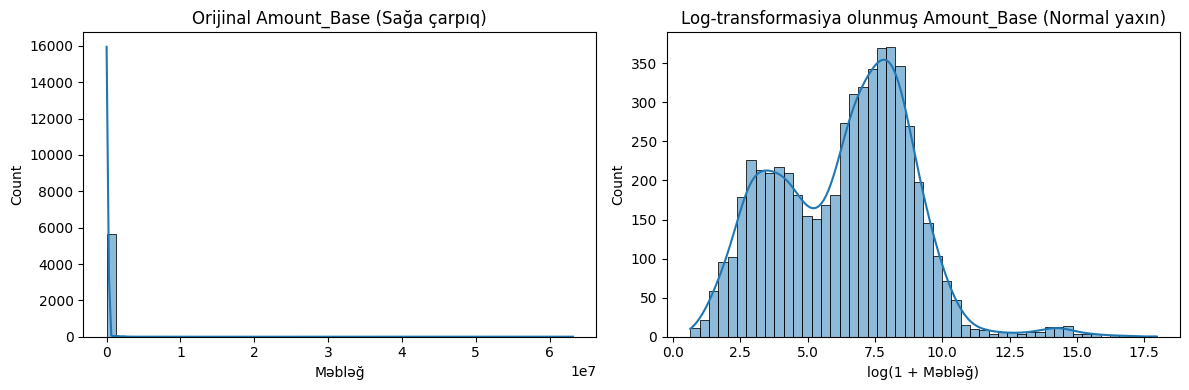

In [ ]:
# Orijinal və log-transformasiya olunmuş dəyərlər
original = df['Amount_Base']
log_transformed = np.log1p(df['Amount_Base'])  # log(1+x)

# Yan-yana histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(original, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Orijinal Amount_Base (Sağa çarpıq)')
axes[0].set_xlabel('Məbləğ')

sns.histplot(log_transformed, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log-transformasiya olunmuş Amount_Base (Normal yaxın)')
axes[1].set_xlabel('log(1 + Məbləğ)')

plt.tight_layout()
plt.show()

* Amount Base de sağa çarpıqlıq var idi yeni bezi müşterilerin yüksek ödenişleri statistik neticeye tesir edirdi. Müşterilerin 75% aşağı ödenişler edir.
*  İkinci qrafikdə loqarifmik transformasiya tətbiq etdik.Böyük dəyərlər kiçildi, kiçik dəyərlər bir az böyüdü.


In [ ]:
#Ödeniş növüne göre statistik deyerleri yoxlayırıq
print("\nTRANSAKSİYA TİPİ ÜZRƏ STATİSTİKA")
tx_type_stats = df.groupby('TransactionType')['Amount_Base'].agg(['count', 'mean', 'median', 'std', 'sum'])
print(tx_type_stats)


TRANSAKSİYA TİPİ ÜZRƏ STATİSTİKA
                 count          mean  median           std           sum
TransactionType                                                         
Credit            1852  78666.098979  850.03  1.563682e+06  1.456896e+08
Debit             2905  37669.633597  826.36  4.704286e+05  1.094303e+08
Refund             914  39211.342177  931.27  6.882239e+05  3.583917e+07


* ödeniş növlerinde median mebleğler demek ölar bir birine yaxındır.
Credit- 850, Debit - 826, Refund - 931

*   Lakin ortalama məbləğlər çox yüksəkdir (Credit-də 78 min, Debit-də 37 min). Bu fərq, hər ödəniş növü daxilində bir neçə çox böyük məbləğli əməliyyatın olması ilə izah olunur. Xüsusilə Credit-də bu böyük məbləğlər ümumi dövriyyəni (145 milyon) artırır.

* ödeniş növüne göre xüsusi monitorinqe ehtiyac yoxdur. Ancaq Geri qaytarmaları azaltmaq üçün müeyyen şirket daxili düzenlemeler ve yoxlanışlar aparılmalıdır.



In [ ]:
from scipy.stats import f_oneway

# Kategoriyalara göre hipotez testi
# Kateqoriya qruplarını log‑məbləğlərə görə yığın
groups = [df[df['Category'] == cat]['Amount_Base_log'].dropna() for cat in df['Category'].unique()]
f_stat, p_cat = f_oneway(*groups)
print(f"Kateqoriya ANOVA p-value: {p_cat}")

Kateqoriya ANOVA p-value: 0.9706105557516481


In [ ]:
# Əvvəlcə həftə sonu sütunu yaradın
df['IsWeekend'] = df['Date'].dt.dayofweek >= 5  # 5 = Cümə, 6 = Şənbə
# Sonra iki qrupu müqayisə edin (t-test)
from scipy.stats import ttest_ind
weekend = df[df['IsWeekend'] == True]['Amount_Base_log'].dropna()
weekday = df[df['IsWeekend'] == False]['Amount_Base_log'].dropna()
t_stat, p_weekend = ttest_ind(weekend, weekday, equal_var=False)
print(f"Həftə sonu vs içi p-value: {p_weekend}")

Həftə sonu vs içi p-value: 0.0878985517915182


In [ ]:
#testin doğruluğunu yoxlamaq üçün Mann testinden isitfade edirik.
from scipy.stats import mannwhitneyu
u_stat, p_mw = mannwhitneyu(weekend, weekday, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p_mw}")

Mann-Whitney U p-value: 0.15030827400425972


In [ ]:
# Həftə sonu və içi üçün neçə əməliyyat olduğunu göstər
print("Həftə sonu əməliyyat sayı:", len(weekend))
print("Həftə içi əməliyyat sayı:", len(weekday))

# Kateqoriyaların hər birində neçə əməliyyat var?
print(df['Category'].value_counts())

Həftə sonu əməliyyat sayı: 1580
Həftə içi əməliyyat sayı: 4091
Category
Dining           602
Groceries        601
Education        593
Electronics      592
Automotive       579
Entertainment    555
Clothing         543
Travel           543
Utilities        542
Health           521
Name: count, dtype: int64


In [ ]:
#Ölkeler arasında hipotez testi
top_countries = df['Country'].value_counts().head(10).index
groups_country = [df[df['Country'] == c]['Amount_Base_log'].dropna() for c in top_countries]
f_stat_c, p_country = f_oneway(*groups_country)
print(f"Ölkə ANOVA p-value: {p_country}")

Ölkə ANOVA p-value: 0.6910139982343788


Statistik testlər:


*   Kateqoriya ilə məbləğ arasında fərq?
ANOVA p-value > 0.05 → Təsir yoxdur  (Kateqoriya ANOVA p-value: 0.97)
*   Həftə sonu / həftə içi xərcləmə fərqi?
  Mann-Whitney u p-value > 0.05 → Fərq yoxdur (p-value: 0.0878  ve Mann-Whitney U p-value: 0.15)

*   Ölkə ilə məbləğ arasında fərq?
  ANOVA p-value > 0.05 → Ölkə məbləğə təsir etmir (Ölkə ANOVA p-value: 0.69)
*   Hefte sonu ve Hefte içiHefte içi - 4091 hefte sonu 1580 emelyat olmuşdur. İnsanlar hefte içi daha çox ödeniş edir ama orta mebleğ deyişmir.  Hefte sonu satışları artırmaq üçün kampanyaların sayı artırılmalıdır. Müeyyenj edirim ve bonus kampanyaları satışı artırmasına kömek ede biler.


In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df_time = df.set_index('Date')

In [ ]:
#en çox pul xerclenen cadegoriayalar
df.groupby("Category")["Amount_Base"].sum().sort_values(ascending=False)


#Burada gördüyümüz kimi en çox pul xerclenen kategoriya Elektronikadır.

,Amount_Base
Category,
Electronics,91574160.62
Clothing,35014985.77
Health,30997740.18
Education,29518279.60
Automotive,25383545.49
Groceries,24738585.76
Travel,14699228.01
Utilities,13944912.33
Entertainment,12784156.66


In [ ]:
df.groupby("Merchant")["Amount_Base"].sum().sort_values(ascending=False)

,Amount_Base
Merchant,
Swiggy,86438781.48
Electroworld,50316508.39
Localmart,33334461.25
Shopeasy,20484150.44
Zomato,20056245.71
Bigbasket,19015113.05
Amazon,17617850.17
Autozone,10342978.65
Flipkart,9292168.42


*  En çox ödeniş edilen kategoriya Elektronika ve en çox ödeniş edilen market ise Swiggy-dır.
*   Tövsiye: Elktronika kategoriyasına tehlükesizlik tedbirlerinin artırılması.
Swiggy startejik terefdaşlıqlar qurmalıdır.



In [ ]:
#en çox istifade olunan Marketler
df["Merchant"].value_counts().head(10)

#Aralarında cüzi ferq olsada en çox istifade edilen market Paytm mall-dur.

,count
Merchant,
Paytm Mall,428
Flipkart,426
Bigbasket,420
Starbucks,417
Zomato,413
Localmart,412
Amazon,411
Swiggy,400
Autozone,400


In [ ]:
#ölkeler üzre xercler
df.groupby("Country")["Amount_Base"].sum().sort_values(ascending=False)

#Ölkeler arasında en yüksek Amerikadır.

,Amount_Base
Country,
USA,88508182.62
UAE,47623230.41
UK,47617905.08
Canada,44563057.66
Australia,44444804.32
India,18201887.57


 *  Hansı ölkede olmasından aslı olmayaraq müşteriler eyni orta mebleğde ödeniş edirler. Günümüze baxsaq her ölkede ortalama qazanc eyni olmadığından feqli limit siyasetleri aparıla biler.




In [ ]:
#fraud analizi (dolandırıcılıq)
df["IsFraud"].value_counts()

,count
IsFraud,
No,5610
Yes,61


In [ ]:
tx_counts = df['TransactionType'].value_counts()
fig = go.Figure(data=[go.Pie(labels=tx_counts.index, values=tx_counts.values)])
fig.update_layout(title_text='Əməliyyat Növü Paylanması')
fig.show()

#en çox ödeniş növünün Debet olduğunu görürük.

In [ ]:
top_categories = df['Category'].value_counts().head(10)
fig_bar_chart = go.Figure(data=[go.Bar(
    x=top_categories.values[::-1],
    y=top_categories.index[::-1],
    orientation='h',
    marker_color=px.colors.qualitative.Plotly[1]
)])
fig_bar_chart.update_layout(title_text='Sayına görə Ən Yüksək Kateqoriyalar')
fig_bar_chart.show()

#en çox istifade edilen kategoriya ise yemek ve baqqal ardınca ise tehsil kategoriyasıdır

*  Kategoriyalara göre
her kategoriyada 521-600 arası emelyat aparılmışdır buda balanslı paylanmanı gösterir.
*   Ferqlenmesini ve satışın artmasını istediyimiz kategoriyada müyyen kampanyalar veya resuslar xercleye bilerik.



In [ ]:
fraud_by_cat = df[df['IsFraud']=='Yes']['Category'].value_counts().head(8)[::-1]
fig_fraud_by_cat_chart = go.Figure(data=[go.Bar(x=fraud_by_cat.values, y=fraud_by_cat.index, orientation='h',
                     marker_color=px.colors.qualitative.Plotly[5])])
fig_fraud_by_cat_chart.update_layout(title_text='Fırıldaqçılıq Hallarının Kateqoriyalar Üzrə Paylanması')
fig_fraud_by_cat_chart.show()

#en çox fırıldaqçılıq geyim kategoriyasıda olduğunu göre

*  Fraud yeni dolandırıcılıq analizi
 ümumi saxtakarlıq 63 eded yeni toplamda (1.06%) olmuşdur.

*   En çox saxtakarlıq Geyim kategoriyasında olmuştur.Dolandırıcılıq analizi aşağı olsada geyim kategoriyası risklidir.Tövsiye ise geyim kategoriyasında elave yoxlamalar keçirilsin.



#Müşteri analizi

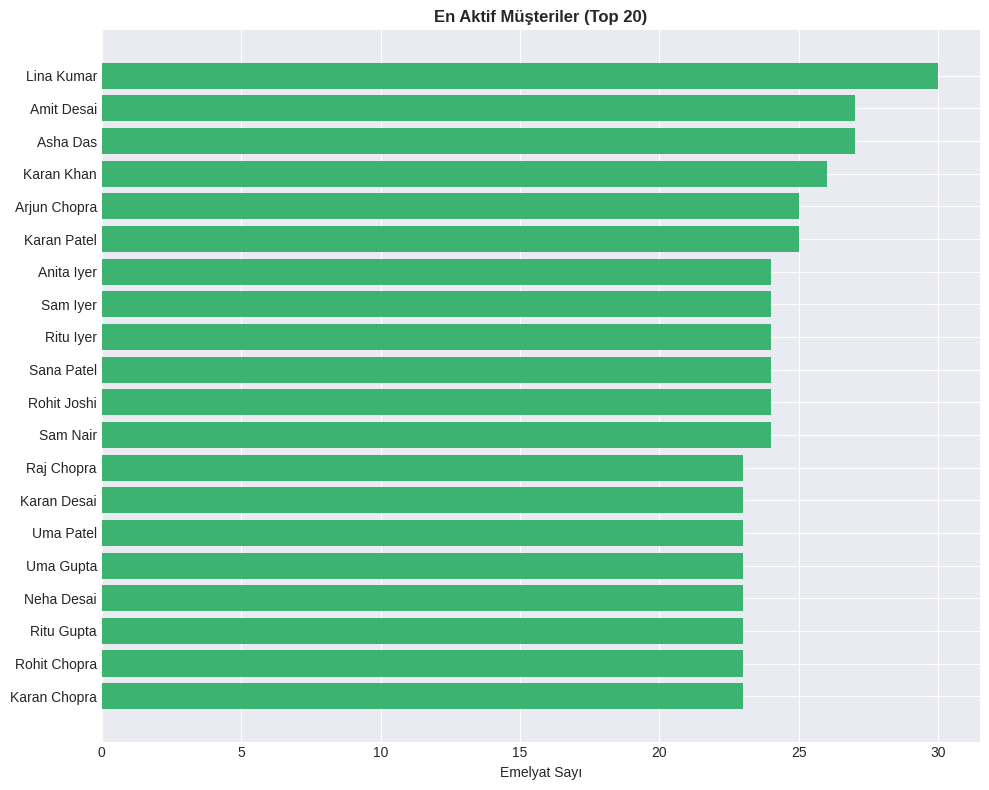

In [ ]:
top_customers = df['AccountName'].value_counts().head(20)[::-1]

fig, ax = plt.subplots(figsize=(10,8))
ax.barh(top_customers.index, top_customers.values, color='mediumseagreen')
ax.set_title('En Aktif Müşteriler (Top 20)', fontsize=12, fontweight='bold')
ax.set_xlabel('Emelyat Sayı')
plt.tight_layout()
plt.show()
#en aktif müşterileri tapmaq üçün istifade ederik bu şekilde ona özel endirimler ve kampanyalarıda onlara suna bilerik

*  En aktif müşteri
Qrafikde en çox emelyat eden 20 müşteri gösterilir ve onların ümumi emelyat hecmi digerlerinden qat-qat yüksektir. Burada ise Pareto prinsipi işleyir. Az sayda müşteri ümumi dövriyenin böyük payını yaradır.
*  Tövsiye: VIP program ve ferdi endirimler istifade olunsun.



In [ ]:
df.to_csv("clean_data.csv", index=False)